### 安装环境

In [1]:
%pip install torch torchvision -i https://pypi.tuna.tsinghua.edu.cn/simple
%pip install matplotlib -i https://pypi.tuna.tsinghua.edu.cn/simple
%pip install torch-pruning -i https://pypi.tuna.tsinghua.edu.cn/simple
%pip install onnx onnxscript -i https://pypi.tuna.tsinghua.edu.cn/simple

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.6/526.6 MB 8.4 MB/s  0:00:560:00:0100:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 8.2 MB/s  0:00:00 eta 0:00:01m
  Using cached filelock-3.32.4-py3-none-any.whl (99 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 818.2/818.2 kB 6.2 MB/s  0:00:00
  Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 6.1 MB/s  0:00:00 eta 0:00:01
  Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl (206 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 5.2 MB/s  0:00:01 eta 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.2/366.2 MB 7.5 MB/s  0:00:470:00:0100:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.1/170.1 MB 10.5 MB/s  0:00:16:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.0/206.0 MB 9.6 MB/s  0:00:210:00:0100:01
     ━━━━━━━━

### 神经网络模型

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

model = Model()
print("create model successfully")

create model successfully


### 数据集MNIST处理

In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(
    root="./dataset",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_dataset = datasets.MNIST(
    root="./dataset",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1000,
    shuffle=False
)

print("训练集大小:", len(train_dataset))
print("batch 数量:", len(train_loader))
print("测试集大小:", len(test_dataset))
print("batch 数量:", len(test_loader))

训练集大小: 60000
batch 数量: 938
测试集大小: 10000
batch 数量: 10


### 模型训练

In [4]:
import os
import torch.nn.functional as F
from torch.optim import Adadelta

optimizer = Adadelta(
    model.parameters(),
    lr=1.0
)

epochs = 5

for epoch in range(epochs):

    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        optimizer.zero_grad()
        output = model(images)
        loss = F.nll_loss(output, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        pred = output.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total

    print(
        f"Epoch {epoch + 1}/{epochs}, "
        f"Loss: {avg_loss:.4f}, "
        f"Accuracy: {accuracy:.2f}%"
    )

print("train successfully")

os.makedirs("./model", exist_ok=True)

torch.save(
    model,
    "./model/model.pt"
)

print("save successfully")

Epoch 1/5, Loss: 0.1982, Accuracy: 93.93%
Epoch 2/5, Loss: 0.0790, Accuracy: 97.73%
Epoch 3/5, Loss: 0.0609, Accuracy: 98.24%
Epoch 4/5, Loss: 0.0511, Accuracy: 98.50%
Epoch 5/5, Loss: 0.0454, Accuracy: 98.67%
train successfully
save successfully


### 模型测试

In [4]:
import torch
import torch.nn.functional as F

def test(model):
    model.eval()

    test_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:

            output = model(images)

            loss = F.nll_loss(output, labels)
            test_loss += loss.item()

            predictions = output.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)


    avg_loss = test_loss / len(test_loader)
    accuracy = 100 * correct / total

    print(f"Test Loss: {avg_loss:.4f}")
    print(f"Test Accuracy: {accuracy:.2f}%")

    print("test successfully")

model = torch.load("model/model.pt", weights_only=False)
test(model)

Test Loss: 0.0328
Test Accuracy: 99.07%
test successfully


### 计算内存大小

In [5]:
def memory_size(model):
    
    model_memory = 0

    for param in model.parameters():
        model_memory += param.numel() * param.element_size()

    for buffer in model.buffers():
        model_memory += buffer.numel() * buffer.element_size()

    model_memory_mib = model_memory / (1024 ** 2)

    print(f"Model Memory: {model_memory_mib:.2f} MiB")

model = torch.load(
    "model/model.pt",
    weights_only=False
)

model = torch.load("model/model.pt", weights_only=False)
memory_size(model)

Model Memory: 4.58 MiB


### 可视化demo预测结果

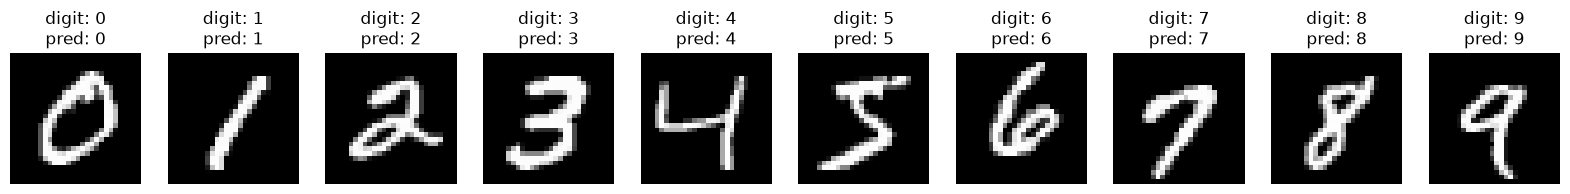

In [6]:
import torch
import matplotlib.pyplot as plt

from PIL import Image
from torchvision import transforms

def visualize_predictions(model):
    plt.figure(figsize=(20, 3))
    demo_inputs = []

    for digit in range(10):
        image = Image.open(f"./demo/{digit}.png").convert("L")
        input_tensor = transform(image)
        demo_inputs.append(input_tensor)

    demo_inputs = torch.stack(demo_inputs)

    model.eval()

    with torch.no_grad():
        predictions = model(demo_inputs).argmax(dim=1)

    for digit in range(10):
        image = Image.open(f"./demo/{digit}.png").convert("L")
        plt.subplot(1, 10, digit + 1)
        plt.imshow(image, cmap="gray")
        plt.title(
            f"digit: {digit}\n"
            f"pred: {predictions[digit].item()}"
        )

        plt.axis("off")

    plt.show()

model = torch.load("model/model.pt", weights_only=False)
visualize_predictions(model)

### 结构化剪枝

In [10]:
import torch
import torch.nn as nn
import torch_pruning as tp

model = torch.load("model/model.pt", weights_only=False)

x = torch.randn(1, 1, 28, 28)

example_inputs = torch.randn(1, 1, 28, 28)

importance = tp.importance.MagnitudeImportance(p=1)

pruning_ratio = 0.7

ignored_layers = [model.fc2]

pruner = tp.pruner.MagnitudePruner(
    model,
    example_inputs,
    importance=importance,
    pruning_ratio=pruning_ratio,
    ignored_layers=ignored_layers
)

# 执行结构化剪枝
pruner.step()

print(model)

print("structured pruning successfully")

Model(
  (conv1): Conv2d(1, 9, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(9, 19, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2736, out_features=38, bias=True)
  (fc2): Linear(in_features=38, out_features=10, bias=True)
)
structured pruning successfully


Test Loss: 0.6967
Test Accuracy: 86.84%
test successfully
Model Memory: 0.40 MiB


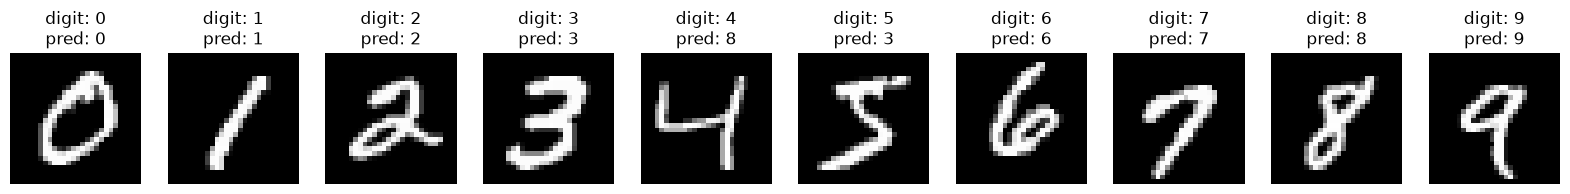

In [11]:
test(model)
memory_size(model)
visualize_predictions(model)

### Fine-Tune 微调

In [12]:
import torch
import torch.nn.functional as F

# 微调优化器
optimizer = torch.optim.Adadelta(
    model.parameters(),
    lr=1e-3
)

fine_tune_epochs = 5

for epoch in range(fine_tune_epochs):

    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        optimizer.zero_grad()

        output = model(images)

        loss = F.nll_loss(output, labels)

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

        predictions = output.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)
    accuracy = 100 * correct / total

    print(
        f"Fine-tune Epoch {epoch + 1}/{fine_tune_epochs}, "
        f"Loss: {avg_loss:.4f}, "
        f"Accuracy: {accuracy:.2f}%"
    )

print("fine-tune successfully")

torch.save(
    model,
    "./model/model_pruned.pt"
)

print("save suceessfully")

Fine-tune Epoch 1/5, Loss: 0.8276, Accuracy: 75.99%
Fine-tune Epoch 2/5, Loss: 0.6496, Accuracy: 82.46%
Fine-tune Epoch 3/5, Loss: 0.5533, Accuracy: 85.18%
Fine-tune Epoch 4/5, Loss: 0.4909, Accuracy: 86.83%
Fine-tune Epoch 5/5, Loss: 0.4488, Accuracy: 87.61%
fine-tune successfully
save suceessfully


Test Loss: 0.2046
Test Accuracy: 97.32%
test successfully
Model Memory: 0.40 MiB


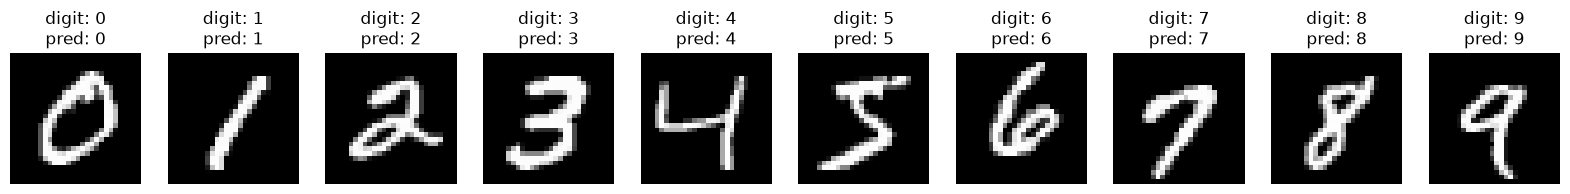

In [13]:
model = torch.load("model/model_pruned.pt", weights_only=False)

test(model)
memory_size(model)
visualize_predictions(model)

### 导出为onnx

In [14]:
import torch

model.eval()

dummy_input = torch.randn(1, 1, 28, 28)

torch.onnx.export(
    model,
    dummy_input,
    "model/model_pruned_fp32.onnx",

    input_names=["input"],
    output_names=["output"],

    dynamic_axes = {
        'input': {0: 'batch_size'},
        'output': {0: 'batch_size'}
    },
    
    opset_version=18,
)

print("ONNX export successfully")

/tmp/ipykernel_7862/2246565239.py:7: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(


[torch.onnx] Obtain model graph for `Model([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Model([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...
[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX export successfully


/home/hzc/anaconda3/envs/python3.14/lib/python3.14/copyreg.py:104: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


### 检测onnx文件

In [15]:
import onnx

onnx_model = onnx.load("./model/model_pruned_fp32.onnx")

onnx.checker.check_model(onnx_model)

print("ONNX model check passed")

ONNX model check passed
